In [1]:
import json
import os
from collections import Counter
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

# ── Change this to your results folder ──────────────────────────────────────
# RESULTS_DIR = "textvqa_results/qwen3vl-2B-quan/iou_selection"   # or textvqa_results_qwen3vl-4B, etc.
RESULTS_DIR = "textvqa_results"   # or gqa_results_qwen3vl-4B, etc.
TOP_N       = 10          # how many top heads to display in the bar chart
# ─────────────────────────────────────────────────────────────────────────────


In [2]:
head_counter   = Counter()   # L{l}H{h}  →  count
sample_count   = 0
missing        = []

results_path = Path(RESULTS_DIR)
for json_file in sorted(results_path.rglob("selected_heads.json")):
    try:
        data = json.loads(json_file.read_text())
    except Exception as e:
        missing.append((str(json_file), str(e)))
        continue

    sample_count += 1
    for head in data.get("selected_heads", []):
        label = f"L{head['layer']}H{head['head']}"
        head_counter[label] += 1

print(f"Scanned {sample_count} samples  |  unique heads seen: {len(head_counter)}")
if missing:
    print(f"  ⚠ Could not read {len(missing)} file(s): {missing[:5]}")


Scanned 914 samples  |  unique heads seen: 208


In [142]:
df = (
    pd.DataFrame(head_counter.most_common(), columns=["head", "count"])
    .assign(
        layer      = lambda d: d["head"].str.extract(r"L(\d+)H").astype(int),
        head_idx   = lambda d: d["head"].str.extract(r"H(\d+)$").astype(int),
        pct        = lambda d: (d["count"] / sample_count * 100).round(1),
    )
    .reset_index(drop=True)
)
df.index += 1                     # 1-based rank
df.index.name = "rank"

print(f"\nTop {min(TOP_N, len(df))} most frequent localization heads  "
      f"(out of {sample_count} samples)\n")
display(df.head(TOP_N))



Top 10 most frequent localization heads  (out of 200 samples)



,head,count,layer,head_idx,pct
rank,,,,,
1,L2H15,42,2,15,21.0
2,L5H5,33,5,5,16.5
3,L21H13,28,21,13,14.0
4,L20H8,23,20,8,11.5
5,L4H12,22,4,12,11.0
6,L8H3,21,8,3,10.5
7,L4H11,20,4,11,10.0
8,L20H6,19,20,6,9.5
9,L3H14,19,3,14,9.5


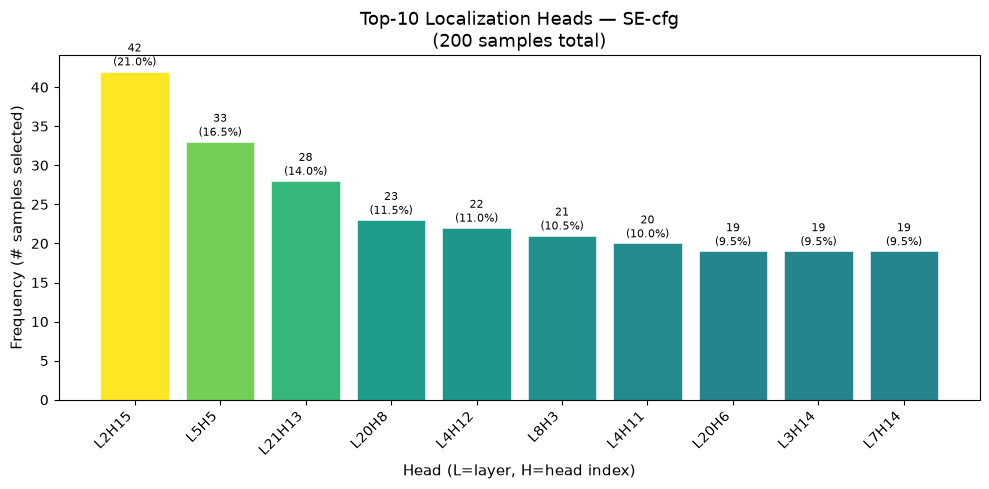

Saved → gqa_results/SE-cfg_head_frequency.png


In [143]:
plot_df = df.head(TOP_N)

fig, ax = plt.subplots(figsize=(max(10, TOP_N * 0.7), 5))

bars = ax.bar(
    plot_df["head"],
    plot_df["count"],
    color=plt.cm.viridis([v / plot_df["count"].max() for v in plot_df["count"]]),
    edgecolor="white",
    linewidth=0.4,
)

# Annotate bars with count + %
for bar, (_, row) in zip(bars, plot_df.iterrows()):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.3,
        f"{int(row['count'])}\n({row['pct']}%)",
        ha="center", va="bottom", fontsize=8,
    )

ax.set_xlabel("Head (L=layer, H=head index)", fontsize=11)
ax.set_ylabel("Frequency (# samples selected)", fontsize=11)
ax.set_title(
    f"Top-{TOP_N} Localization Heads — {Path(RESULTS_DIR).name}\n"
    f"({sample_count} samples total)",
    fontsize=13,
)
ax.yaxis.set_major_locator(mticker.MaxNLocator(integer=True))
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig(f"{RESULTS_DIR}_head_frequency.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved → {RESULTS_DIR}_head_frequency.png")


In [144]:
head_list = []
for head in df.head(TOP_N).iterrows():
    head_label = head[1]["head"]
    layer_idx = head[1]["layer"]
    head_idx  = head[1]["head_idx"]
    head_list.append((layer_idx, head_idx))

head_list   

[(2, 15),
 (5, 5),
 (21, 13),
 (20, 8),
 (4, 12),
 (8, 3),
 (4, 11),
 (20, 6),
 (3, 14),
 (7, 14)]

In [145]:
# # How often each layer appears as a selected localization layer
# layer_counter = Counter(df["layer"].repeat(df["count"]))
# layer_df = pd.DataFrame(
#     sorted(layer_counter.items()), columns=["layer", "count"]
# ).assign(pct=lambda d: (d["count"] / sample_count * 100).round(1))

# fig, ax = plt.subplots(figsize=(12, 3))
# ax.bar(layer_df["layer"], layer_df["count"], color="steelblue", edgecolor="white")
# ax.set_xlabel("Layer", fontsize=11)
# ax.set_ylabel("Frequency", fontsize=11)
# ax.set_title("Localization head selections by layer", fontsize=13)
# ax.yaxis.set_major_locator(mticker.MaxNLocator(integer=True))
# plt.tight_layout()
# plt.show()


In [146]:
# ── mIoU & Localization Metrics ──────────────────────────────────────────────
# For every sample folder in RESULTS_DIR:
#   1. Load mask.png  (binary, white = predicted region).
#   2. Look up the matching entry in textvqa_200_samples.jsonl by image_id.
#   3. Build a GT mask from the bboxes (union of all boxes → binary mask).
#   4. Compute IoU, mIoU (mean over fg/bg), Dice/F1, Precision, Recall.
# ─────────────────────────────────────────────────────────────────────────────
import numpy as np
from PIL import Image

JSONL_PATH = "gqa_200_samples.jsonl"

# ── 1. Load ground-truth metadata indexed by image_id ────────────────────────
gt_by_id = {}
with open(JSONL_PATH) as f:
    for line in f:
        entry = json.loads(line)
        gt_by_id[entry["image_id"]] = entry

print(f"Loaded {len(gt_by_id)} GT entries from {JSONL_PATH}")

# ── 2. Helper: build binary GT mask from bboxes ───────────────────────────────
def bboxes_to_mask(bboxes, h, w):
    """Return a boolean (H, W) mask; True where any bbox covers the pixel."""
    mask = np.zeros((h, w), dtype=bool)
    for x1, y1, x2, y2 in bboxes:
        r0, r1 = int(y1), int(np.ceil(y2))
        c0, c1 = int(x1), int(np.ceil(x2))
        r0, r1 = max(0, r0), min(h, r1)
        c0, c1 = max(0, c0), min(w, c1)
        mask[r0:r1, c0:c1] = True
    return mask

# ── 3. Helper: compute metrics from two boolean masks ─────────────────────────
def compute_metrics(pred_mask, gt_mask):
    """
    pred_mask, gt_mask : boolean numpy arrays of identical shape.
    Returns a dict with IoU (fg), mIoU, Dice, Precision, Recall.
    """
    pred = pred_mask.astype(bool)
    gt   = gt_mask.astype(bool)

    tp = np.logical_and(pred,  gt ).sum()
    fp = np.logical_and(pred,  ~gt).sum()
    fn = np.logical_and(~pred, gt ).sum()
    tn = np.logical_and(~pred, ~gt).sum()

    iou_fg = tp / (tp + fp + fn) if (tp + fp + fn) > 0 else float("nan")
    iou_bg = tn / (tn + fn + fp) if (tn + fn + fp) > 0 else float("nan")
    miou   = float(np.nanmean([iou_fg, iou_bg]))
    dice   = 2 * tp / (2 * tp + fp + fn) if (2 * tp + fp + fn) > 0 else float("nan")
    prec   = tp / (tp + fp)               if (tp + fp) > 0           else float("nan")
    rec    = tp / (tp + fn)               if (tp + fn) > 0           else float("nan")

    return dict(iou_fg=float(iou_fg), iou_bg=float(iou_bg), miou=miou, dice=float(dice),
                precision=float(prec), recall=float(rec))

# ── 4. Iterate over all sample folders ───────────────────────────────────────
records = []
skipped = []
best5 = []
results_path = Path(RESULTS_DIR)
for mask_path in sorted(results_path.rglob("mask.png")):
    image_id = mask_path.parent.name

    if image_id not in gt_by_id:
        skipped.append((image_id, "not in JSONL")); continue
    entry  = gt_by_id[image_id]
    bboxes = entry.get("bboxs", [])
    if not bboxes:
        skipped.append((image_id, "no bboxes")); continue

    img_w, img_h = entry["image_width"], entry["image_height"]

    try:
        pred_img = Image.open(mask_path).convert("L")
    except Exception as e:
        skipped.append((image_id, str(e))); continue

    # Resize mask to GT image dimensions if needed (nearest = preserve binary)
    if pred_img.size != (img_w, img_h):
        pred_img = pred_img.resize((img_w, img_h), Image.NEAREST)

    pred_mask = np.array(pred_img) > 127
    gt_mask   = bboxes_to_mask(bboxes, img_h, img_w)

    m = compute_metrics(pred_mask, gt_mask)
    m["image_id"] = image_id
    m["question"] = entry.get("question", "")
    
    
    records.append(m)

print(f"Evaluated {len(records)} samples  |  skipped {len(skipped)}")
if skipped:
    print("  Skipped:", skipped[:5])


Loaded 200 GT entries from gqa_200_samples.jsonl
Evaluated 200 samples  |  skipped 0



── Summary statistics across all samples ──


,miou,iou_fg,iou_bg,dice,precision,recall
mean,0.3141,0.1295,0.4986,0.2076,0.2025,0.4724
median,0.3072,0.0887,0.5379,0.1630,0.0974,0.4648
std,0.0720,0.1297,0.1544,0.1913,0.2488,0.3185
min,0.1237,0.0000,0.0036,0.0000,0.0000,0.0000
max,0.5128,0.4519,0.7904,0.6225,0.9987,1.0000


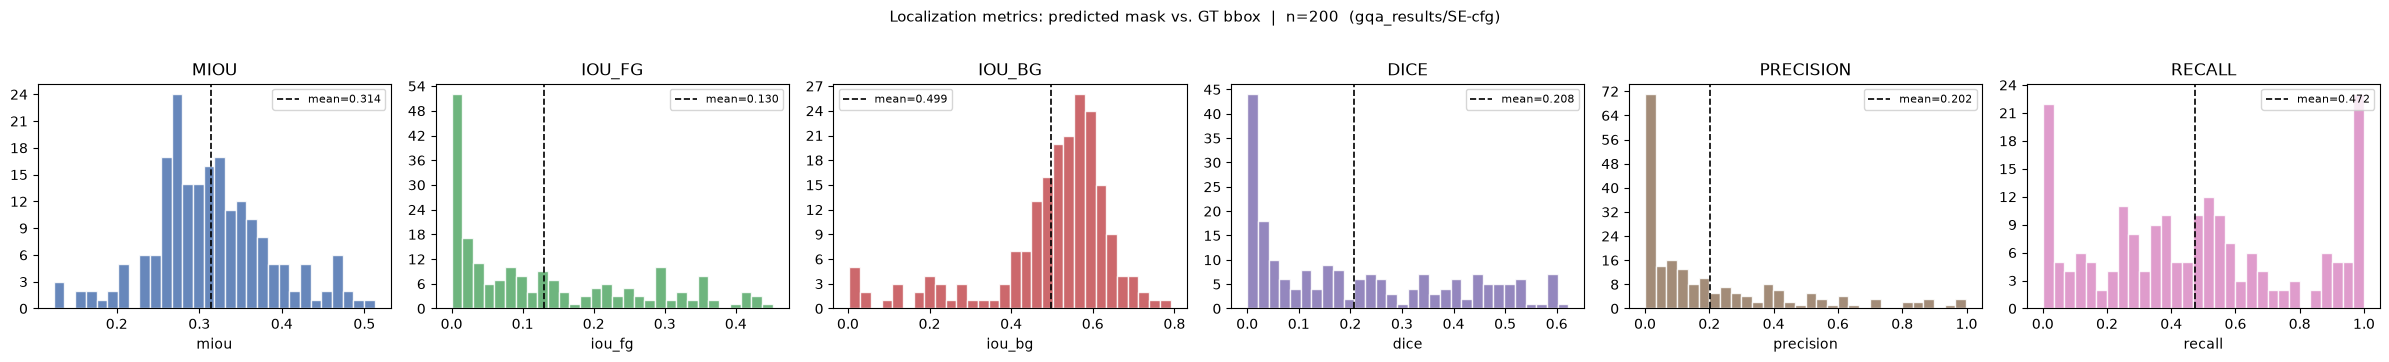

Saved plot → gqa_results/SE-cfg_localization_metrics.png


In [147]:
# ── Aggregate & display results ───────────────────────────────────────────────
metrics_df = pd.DataFrame(records).set_index("image_id")

metric_cols = ["miou", "iou_fg", "iou_bg", "dice", "precision", "recall"]
summary = metrics_df[metric_cols].agg(["mean", "median", "std", "min", "max"])
print("\n── Summary statistics across all samples ──")
display(summary.round(4))

# Distribution plots
fig, axes = plt.subplots(1, len(metric_cols), figsize=(4 * len(metric_cols), 3.5))
colors = ["#4C72B0", "#55A868", "#C44E52", "#8172B3", "#937860", "#DA8BC3"]

for ax, col, color in zip(axes, metric_cols, colors):
    vals = metrics_df[col].dropna()
    ax.hist(vals, bins=30, color=color, edgecolor="white", alpha=0.85)
    ax.axvline(vals.mean(), color="black", linestyle="--", linewidth=1.2,
               label=f"mean={vals.mean():.3f}")
    ax.set_title(col.upper())
    ax.set_xlabel(col)
    ax.legend(fontsize=8)
    ax.yaxis.set_major_locator(mticker.MaxNLocator(integer=True))

plt.suptitle(
    f"Localization metrics: predicted mask vs. GT bbox  |  "
    f"n={len(metrics_df)}  ({RESULTS_DIR})",
    fontsize=11, y=1.02,
)
plt.tight_layout()
out_png = f"{RESULTS_DIR}_localization_metrics.png"
plt.savefig(out_png, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved plot → {out_png}")

# out_csv = f"{RESULTS_DIR}_localization_metrics.csv"
# metrics_df.to_csv(out_csv)
# print(f"Saved CSV  → {out_csv}")


In [148]:
# ── Calculate Average Precision metrics ──────────────────────────────────────
def calculate_ap(iou_values, threshold):
    """Calculate AP at a given IoU threshold"""
    if len(iou_values) == 0:
        return 0.0
    iou_values = np.array(iou_values)
    # Count how many predictions meet the threshold
    matches = (iou_values >= threshold).sum()
    # AP = fraction of predictions with IoU >= threshold
    return matches / len(iou_values)

# Add AP@50 and AP@70 to records (assuming 'iou' or similar column exists)
iou_values = []
for record in records:
    iou_values.append(record.get('iou_fg'))
print("AP@50:", calculate_ap(iou_values, 0.50))
print("AP@70:", calculate_ap(iou_values, 0.70))

AP@50: 0.0
AP@70: 0.0


In [10]:
sorted_rec = sorted(records, key=lambda x: x['iou_fg'], reverse=True)
samples_10 = sorted_rec[:10]
display(pd.DataFrame(samples_10)[["question", "iou_fg", "iou_bg", "miou", "dice", "precision", "recall"]])

,question,iou_fg,iou_bg,miou,dice,precision,recall
0,What is that animal called?,0.778743,0.886715,0.832729,0.875610,0.896795,0.855403
1,What is the man holding?,0.710597,0.863961,0.787279,0.830817,0.763707,0.910859
2,Which kind of toy is it?,0.709575,0.855711,0.782643,0.830118,0.816663,0.844024
3,What animal is on the desk?,0.698567,0.766586,0.732576,0.822537,0.995828,0.700617
4,What vehicle is to the left of the car that lo...,0.678050,0.902431,0.790241,0.808141,0.717401,0.925158
5,Who is holding the umbrella?,0.675711,0.900467,0.788089,0.806477,0.681743,0.987075
6,Who is in front of the bench?,0.671088,0.798737,0.734913,0.803175,0.824419,0.782999
7,What device is the woman playing on?,0.658420,0.901935,0.780178,0.794033,0.689107,0.936652
8,Which kind of vegetable is fried?,0.655929,0.935806,0.795868,0.792219,0.657913,0.995423
9,What appliance is to the right of the stove?,0.653713,0.833305,0.743509,0.790600,0.851322,0.737964


In [11]:
samples_10 = pd.DataFrame(samples_10).set_index("image_id")

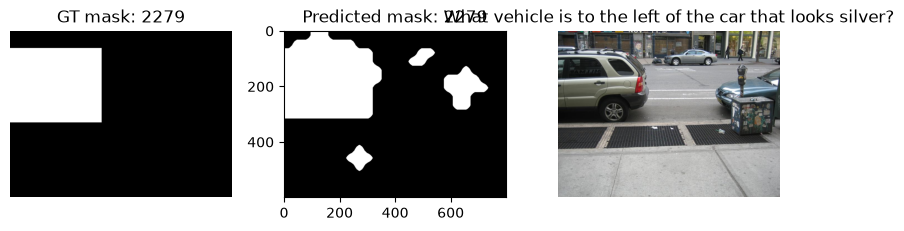

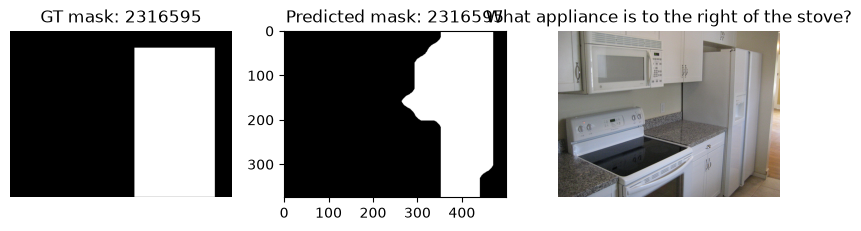

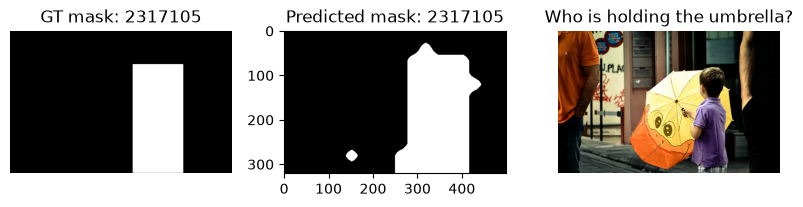

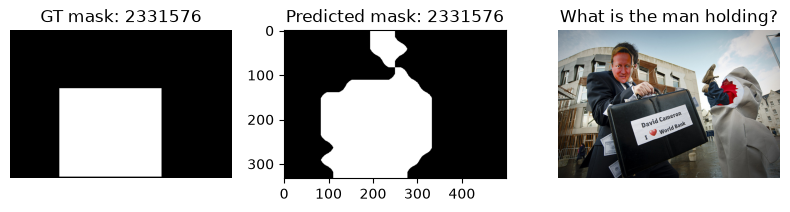

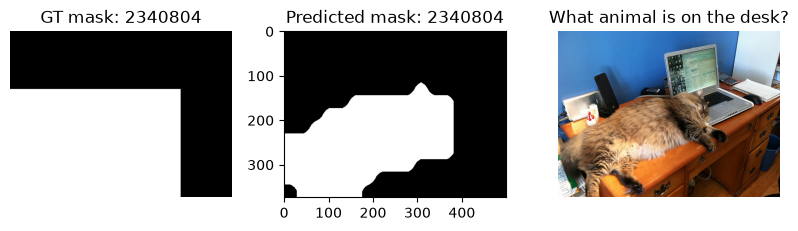

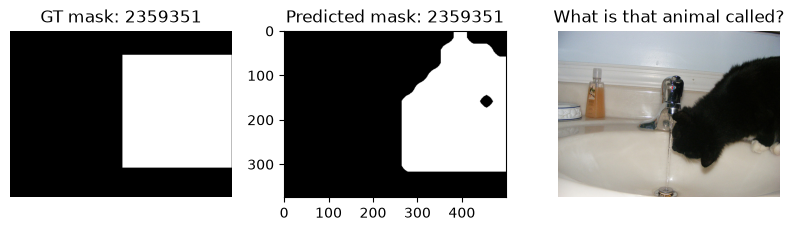

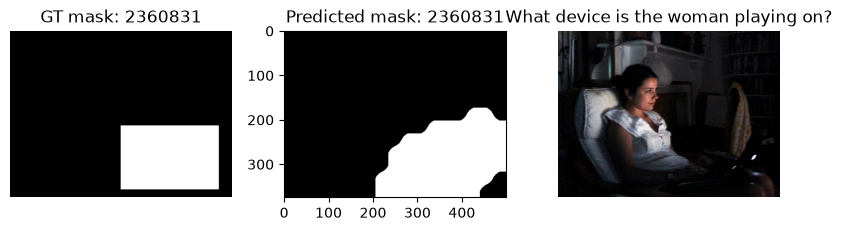

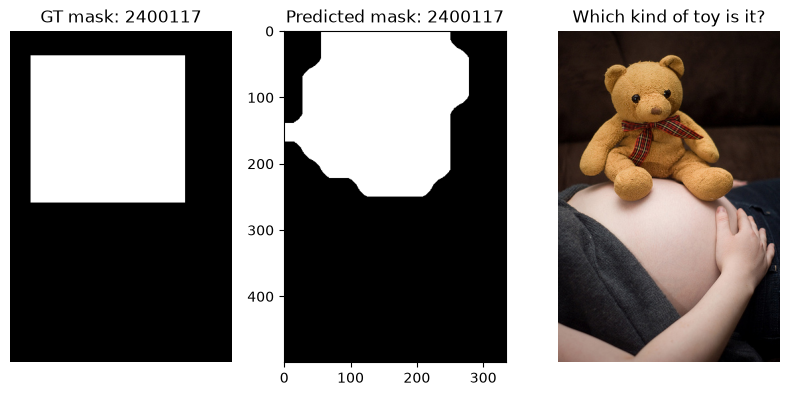

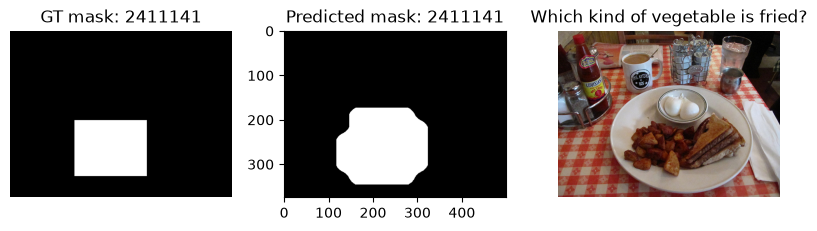

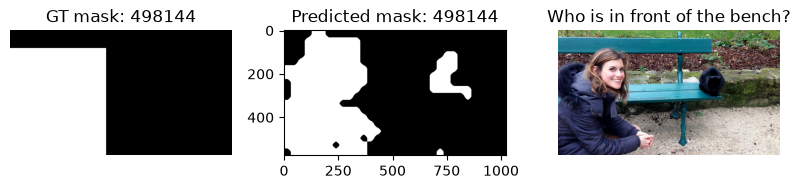

In [12]:
import matplotlib.pyplot as plt
image_folder = "gqa_images"
for mask_path in sorted(results_path.rglob("mask.png")):
    image_id = mask_path.parent.name
    image_path = image_folder + "/" + f"{image_id}.jpg"
    image = Image.open(image_path).convert("RGB")
    if image_id not in samples_10.index:
        continue
        skipped.append((image_id, "not in JSONL")); continue
    entry  = gt_by_id[image_id]
    bboxes = entry.get("bboxs", [])
    question = entry.get("question", "")
    if not bboxes:
        skipped.append((image_id, "no bboxes")); continue

    img_w, img_h = entry["image_width"], entry["image_height"]

    try:
        pred_img = Image.open(mask_path).convert("L")
    except Exception as e:
        skipped.append((image_id, str(e))); continue
    

    
    pred_mask = np.array(pred_img) > 127
    gt_mask   = bboxes_to_mask(bboxes, img_h, img_w)
    plt.figure(figsize=(8, 4))
    plt.subplot(1, 3, 1)
    plt.imshow(gt_mask, cmap="gray")
    plt.title(f"GT mask: {image_id}")
    plt.axis("off")
    plt.subplot(1, 3, 2)
    plt.imshow(pred_mask, cmap="gray")
    plt.title(f"Predicted mask: {image_id}")
    plt.subplot(1, 3, 3)
    plt.imshow(image)
    plt.title(question)
    plt.axis("off")
    plt.tight_layout()
    plt.show()

